In [39]:
# !pip install matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
pd.set_option("display.float_format","{:,.2f}".format)


In [7]:
base_dir = Path.cwd()
df = pd.read_parquet(f'{base_dir}/files/sales.parquet')

In [ ]:
# setting the RFM to my clients
clientes = df.groupby('cliente').agg(
    montoventapesos = ('montoventapesos','sum'),
    frecuencia = ('factura', 'nunique'),
    recencia = ('fechafactura',lambda x: (pd.Timestamp.now()-x.max()).days)
).reset_index()


,cliente,montoventapesos,frecuencia,recencia
0,1000000422,"270,879.98",15,28
1,10000008,"223,311.98",2,7
2,1000002095,"57,641.61",3,433
3,1000005315,"489,502.39",16,26
4,1000005684,"27,395.00",1,454
...,...,...,...,...
102310,999371,"1,640,421.70",36,19
102311,9994156,"1,134,201.23",17,67
102312,9994575,"28,643,316.72",40,60
102313,9994913,"20,855,275.80",39,4


# First sight to the distribution of my data

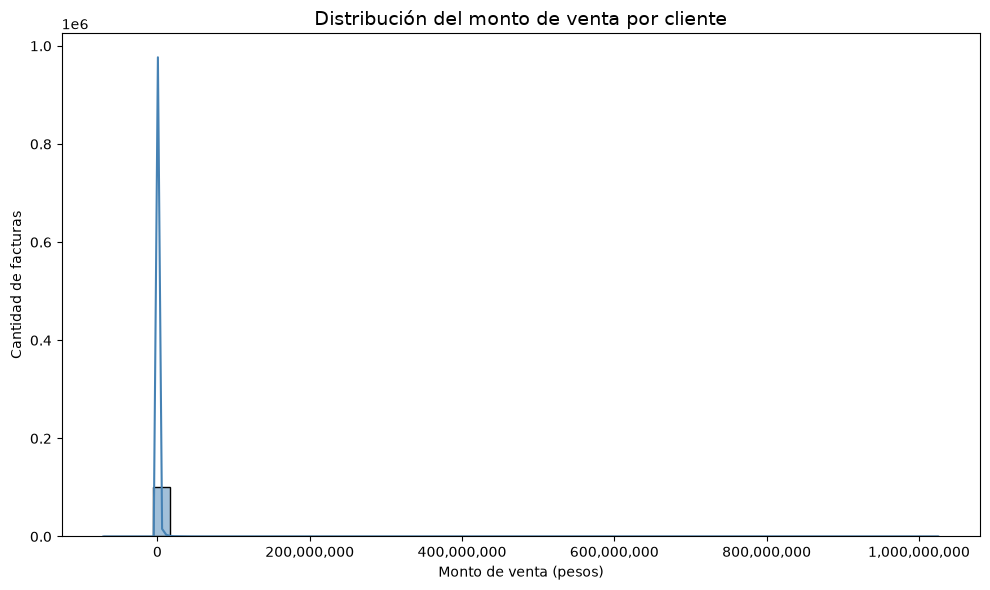

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=clientes,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=ax
)
ax.set_title('Distribución del monto de venta por cliente', fontsize=14)
ax.set_xlabel('Monto de venta (pesos)')
ax.set_ylabel('Cantidad de facturas')
#ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

> ***The data is skewed to the the right, so in this ocassion we are going to apply a log scale (I have done some researchs to look for it)***

In [32]:
devoluciones = clientes[clientes['montoventapesos']<0]
clientes_positivos = clientes[clientes['montoventapesos']>=0]
q1 = clientes['montoventapesos'].quantile(0.25)
q3 = clientes['montoventapesos'].quantile(0.75)
clientes_IQR = clientes_positivos[(clientes_positivos['montoventapesos']>=q1) &(clientes_positivos['montoventapesos']<=q3)]
clientes_higher_q3 = clientes_positivos[(clientes_positivos['montoventapesos']>q3)]
clientes_lower_q1 = clientes_positivos[(clientes_positivos['montoventapesos']<q1)]


c:\Users\practicanteit3\OneDrive - TRONEX S.A\Documentos\Proyectos\Market_Basket_Analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


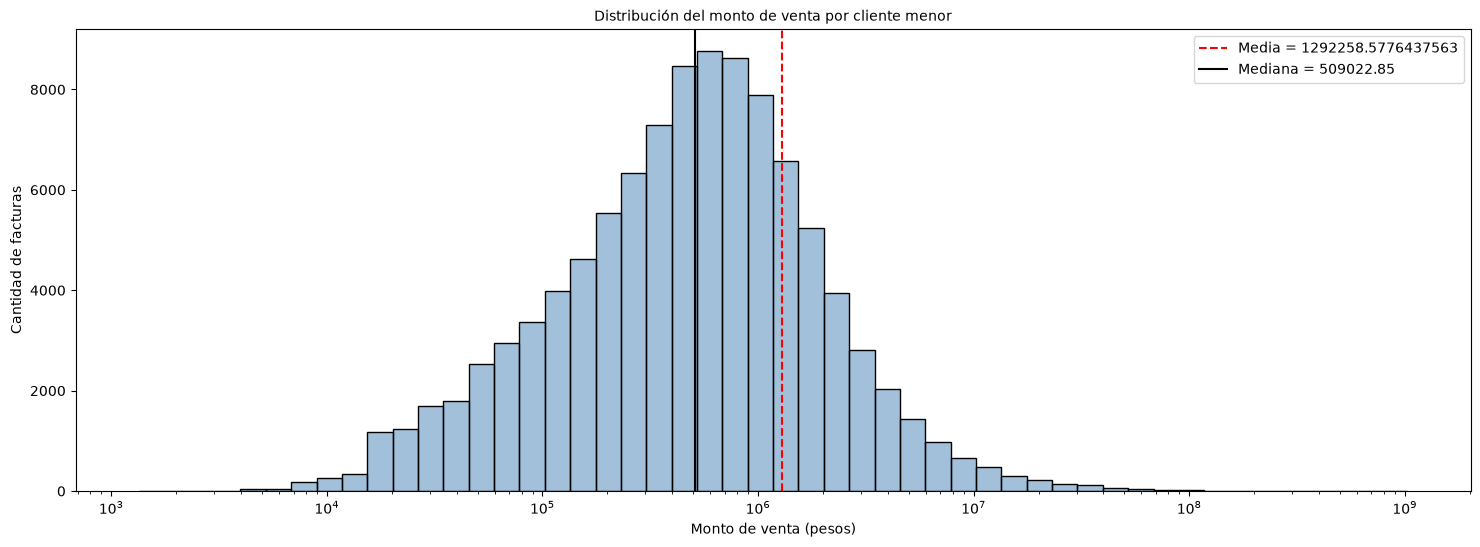

In [38]:
fig, axes = plt.subplots(figsize=(18, 6))
sns.histplot(
    data=clientes_positivos,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=axes,
    log_scale=True
)

media = clientes_positivos['montoventapesos'].mean()
median = clientes_positivos['montoventapesos'].median() 
axes.set_title('Distribución del monto de venta por cliente menor', fontsize=10)
axes.set_xlabel('Monto de venta (pesos)')
axes.set_ylabel('Cantidad de facturas')
axes.axvline(media,label=f'Media = {media}', color= 'red',linestyle='--')
axes.axvline(median,label=f'Mediana = {median}', color= 'black',linestyle='-')
#axes[0].ticklabel_format(style='plain', axis='x')
#axes.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes.legend()

# **Machine Learning**
---

In [47]:
clientes_positivos['sale_scaled'] = np.log10(clientes_positivos['montoventapesos'])
clientes_positivos.head()

c:\Users\practicanteit3\OneDrive - TRONEX S.A\Documentos\Proyectos\Market_Basket_Analysis\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,cliente,montoventapesos,frecuencia,recencia,sale_scaled
0,1000000422,"270,879.98",15,28,5.43
1,10000008,"223,311.98",2,7,5.35
2,1000002095,"57,641.61",3,433,4.76
3,1000005315,"489,502.39",16,26,5.69
4,1000005684,"27,395.00",1,454,4.44


In [ ]:
from sklearn.decomposition import PCA

variables = ['frecuencia','recencia','sale_scaled']
x = clientes_positivos[variables]
pca = PCA(n_components=2)

pca.fit()

ModuleNotFoundError: No module named 'sklearn'